455 114
364 91
(array([0, 1]), array([212, 357], dtype=int64))


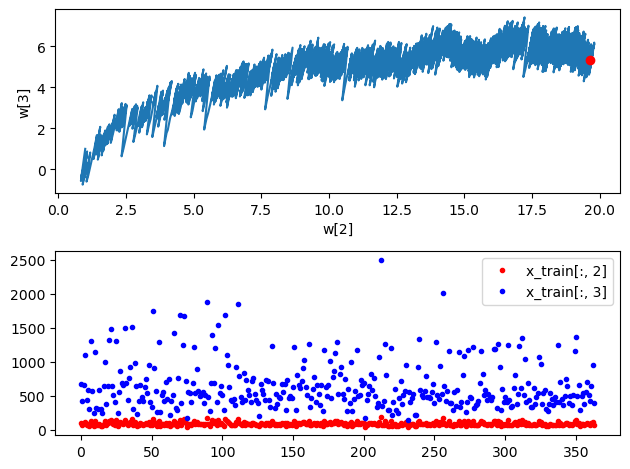

In [72]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class SingleLayer:
    def __init__(self, learning_rate=0.001):
        self.w = None
        self.b = None
        self.losses = []
        self.w_history = []
        self.lr = learning_rate

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z
    
    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())
        np.random.seed(42)
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)
                self.w -= self.lr * w_grad
                self.b -= b_grad
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a) + (1-y[i])*np.log(1-a))
            self.losses.append(loss/len(y))

    
    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        a = self.activation(z)
        return a > 0.5
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)
    

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))
print(np.unique(cancer.target, return_counts=True))

layer = SingleLayer()
layer.fit(x_train, y_train)
# layer.score(x_val, y_val)
w2 = []
w3 = []
for w in layer.w_history:
    w2.append(w[2])
    w3.append(w[3])

ax1 = plt.subplot(2, 1, 1)

ax1.plot(w2, w3)
ax1.plot(w2[-1], w3[-1], 'ro')
ax1.set_xlabel('w[2]')
ax1.set_ylabel('w[3]')

ax2 = plt.subplot(2, 1, 2)
pd.DataFrame({
    'x_train[:, 2]': x_train[:, 2],
    'x_train[:, 3]': x_train[:, 3]
}).plot(ax=ax2, style=['r.', 'b.'])

plt.tight_layout()
plt.show()

위의 상황 처럼 스케일이 서로 다른 요소로 모델을 훈련시키면 가중치를 찾는 경로가 크게 흔들림

w2값은 학습 과정에서 조금씩 최적값에 가까워지지만 w3값이 큰 폭으로 흔들리며 변화하고 있다.
이를 w3에 대한 그래이디언트가 크기 때문에 w3에 따라 가중치가 크게 요동치고 있다 라고 한다.

455 114
364 91
(array([0, 1]), array([212, 357], dtype=int64))


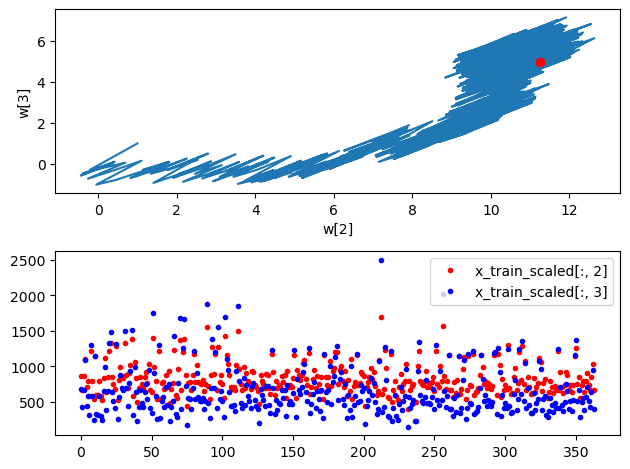

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class SingleLayer:
    def __init__(self, learning_rate=0.001):
        self.w = None
        self.b = None
        self.losses = []
        self.w_history = []
        self.lr = learning_rate

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z
    
    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())
        np.random.seed(42)
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)
                self.w -= self.lr * w_grad
                self.b -= b_grad
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a) + (1-y[i])*np.log(1-a))
            self.losses.append(loss/len(y))

    
    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        a = self.activation(z)
        return a > 0.5
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)
    

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))
print(np.unique(cancer.target, return_counts=True))


x_train_scaled = x_train
x_train_scaled[:, 2] *= 9

layer = SingleLayer()
layer.fit(x_train_scaled, y_train)
# layer.score(x_val, y_val)
w2 = []
w3 = []
for w in layer.w_history:
    w2.append(w[2])
    w3.append(w[3])

ax1 = plt.subplot(2, 1, 1)

ax1.plot(w2, w3)
ax1.plot(w2[-1], w3[-1], 'ro')
ax1.set_xlabel('w[2]')
ax1.set_ylabel('w[3]')

ax2 = plt.subplot(2, 1, 2)
pd.DataFrame({
    'x_train_scaled[:, 2]': x_train_scaled[:, 2],
    'x_train_scaled[:, 3]': x_train_scaled[:, 3]
}).plot(ax=ax2, style=['r.', 'b.'])

plt.tight_layout()
plt.show()

455 114
364 91
(array([0, 1]), array([212, 357], dtype=int64))


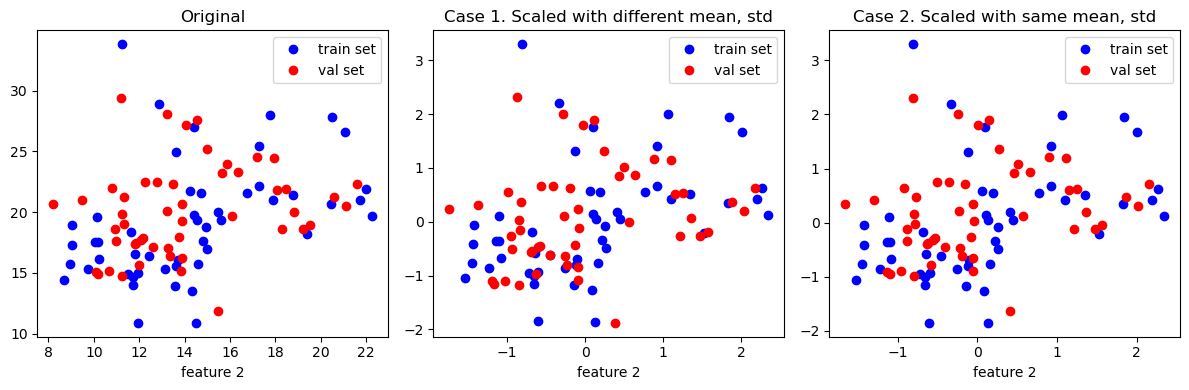

In [133]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class SingleLayer:
    def __init__(self, learning_rate=0.001):
        self.w = None
        self.b = None
        self.losses = []
        self.w_history = []
        self.lr = learning_rate

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z
    
    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())
        np.random.seed(42)
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)
                self.w -= self.lr * w_grad
                self.b -= b_grad
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a) + (1-y[i])*np.log(1-a))
            self.losses.append(loss/len(y))

    
    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        a = self.activation(z)
        return a > 0.5
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)
    

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))
print(np.unique(cancer.target, return_counts=True))

train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

layer = SingleLayer()
layer.fit(x_train_scaled, y_train)
# layer.score(x_val, y_val)
w2 = []
w3 = []
for w in layer.w_history:
    w2.append(w[2])
    w3.append(w[3])

# ax1 = plt.subplot(3, 1, 1)

# ax1.plot(w2, w3)
# ax1.plot(w2[-1], w3[-1], 'ro')
# ax1.set_xlabel('w[2]')
# ax1.set_ylabel('w[3]')

# ax2 = plt.subplot(3, 1, 2)
# pd.DataFrame({
#     'x_train_scaled[:, 2]': x_train_scaled[:, 2],
#     'x_train_scaled[:, 3]': x_train_scaled[:, 3]
# }).plot(ax=ax2, style=['r.', 'b.'])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("Original")
axes[0].plot(x_train[:50, 0], x_train[:50, 1], 'bo')
axes[0].plot(x_val[:50, 0], x_val[:50, 1], 'ro')
axes[0].set_xlabel('feature 1')
axes[0].set_xlabel('feature 2')
axes[0].legend(['train set', "val set"])

val_mean = np.mean(x_val, axis=0)
val_std = np.std(x_val, axis=0)
x_val_scaled = (x_val - val_mean) / val_std

axes[1].set_title("Case 1. Scaled with different mean, std")
axes[1].plot(x_train_scaled[:50, 0], x_train_scaled[:50, 1], 'bo')
axes[1].plot(x_val_scaled[:50, 0], x_val_scaled[:50, 1], 'ro')
axes[1].set_xlabel('feature 1')
axes[1].set_xlabel('feature 2')
axes[1].legend(['train set', "val set"])

x_val_scaled = (x_val - train_mean) / train_std
axes[2].set_title("Case 2. Scaled with same mean, std")
axes[2].plot(x_train_scaled[:50, 0], x_train_scaled[:50, 1], 'bo')
axes[2].plot(x_val_scaled[:50, 0], x_val_scaled[:50, 1], 'ro')
axes[2].set_xlabel('feature 1')
axes[2].set_xlabel('feature 2')
axes[2].legend(['train set', "val set"])

plt.tight_layout()
plt.show()

훈련 세트와 검증 세트를 동일한 비율로 전처리(스케일 조정) 해야 함.

```python
train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

val_mean = np.mean(x_val, axis=0)
val_std = np.std(x_val, axis=0)
x_val_scaled = (x_val - val_mean) / val_std # 같은 비율로 스케일되지 않음! (Case 1)

# -------------------------------------------------------------------------

train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

x_val_scaled = (x_val - train_mean) / train_std # 이 방식이 더 좋음! (Case 2)
```